# Visualizing Convolutional Neural Network (CNN) outputs

Using the Kaggle Cats-and-Dogs dataset from the Dogs vs. Cats challenge (see [here](https://www.kaggle.com/competitions/dogs-vs-cats)), we train a simple CNN for binary classification. </br>
We then visualize CNN layer outputs. This helps us understand how these models work. </br></br>
Training was conducted on a single NVIDIA Blackwell GB203 GPU on Linux Fedora 43 for Workstation. 

## Get image paths

In [1]:
from pathlib import Path
import csv

#root folder containing all subfolders
dataset_dir = Path("/home/simon/Documents/ML_Python/PetImages")

#output CSV file
output_csv = "/home/simon/Documents/ML_Python/catsanddogs.csv"

#image extensions to include
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp"}

rows = []

#iterate through all files recursively
for image_path in dataset_dir.rglob("*"):
    if image_path.is_file() and image_path.suffix.lower() in image_extensions:
        
        #get immediate parent folder name
        subfolder_name = image_path.parent.name
        
        rows.append([
            str(image_path), #full image path
            subfolder_name  #subfolder name
        ])

#write to CSV
with open(output_csv, 
          mode = "w", 
          newline = "", 
          encoding = "utf-8") as f:
    
    writer = csv.writer(f)
    
    #header
    writer.writerow(["image_path", "animal"])
    
    #data rows
    writer.writerows(rows)

print(f"Saved {len(rows)} entries to {output_csv}")

Saved 25000 entries to /home/simon/Documents/Machine learning Python/catsanddogs.csv


## Remove corrupted files

In [3]:
from PIL import Image
import pandas as pd

inputs = pd.read_csv(output_csv)
bad_indices = []

#go through all images
for idx, path in enumerate(inputs["image_path"]):

    #see if an image can be opened
    try:
        img = Image.open(path)
        img.verify()

    #if exception -> file is corrupted
    except:
        print(path)

        bad_indices.append(idx)

print("Total bad images:", len(bad_indices))

/home/simon/Documents/Machine learning Python/PetImages/Cat/666.jpg
/home/simon/Documents/Machine learning Python/PetImages/Dog/11702.jpg
Total bad images: 2


In [4]:
inputs = inputs.drop(bad_indices).reset_index(drop = True)

## Stratified split

In [5]:
df_pre = inputs

#create new column with integers
df_pre["animal_int"] = df_pre["animal"].replace(["Cat", "Dog"],[1, 2])
df_pre.to_csv(output_csv)

In [6]:
from sklearn.model_selection import train_test_split


#Stratified 80/20 split. Casts float CSV labels to int.
df = pd.read_csv(output_csv, 
                 low_memory = False) #read whole file before inferring types

df["animal_int"] = df["animal_int"].astype(int)

assert set(df["animal_int"].unique()) <= {1, 2}, \
    f"Unexpected label values: {sorted(df["animal_int"].unique())}"

train_df, val_df = train_test_split(
    df,
    test_size    = 0.8,
    stratify     = df["animal_int"], #stratify for animal
    random_state = 42,
)


In [7]:
print(len(train_df))
print(len(val_df))

4999
19999


## Preprocessing

In [8]:
#This is considered LEGACY but I do not care
from keras.src.legacy.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

#pull data from dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_df,
    x_col = "image_path",
    y_col = "animal", #choose string, not integer label
    target_size = (150, 150),
    batch_size = 20,
    class_mode = "binary"
)

#pull data from dataframe
validation_generator = test_datagen.flow_from_dataframe(
    dataframe = val_df,
    x_col = "image_path",
    y_col = "animal", #choose string, not integer label
    target_size = (150, 150),
    batch_size = 20,
    class_mode = "binary"
)


I0000 00:00:1778533025.364221   39521 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778533025.397901   39521 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 4999 validated image filenames belonging to 2 classes.
Found 19999 validated image filenames belonging to 2 classes.


## Define model pipeline

In [9]:
from keras import models
from keras import layers

model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation = 'relu', input_shape = (150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation = 'relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation = 'relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation = 'relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(512, activation ='relu'))

#use sigmoid for binary classification
model.add(layers.Dense(1, activation = "sigmoid"))

model.summary()

/home/simon/anaconda3/envs/cnn_visualization/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778533053.154895   39521 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13739 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

## Compile model

In [10]:
from keras import optimizers
from PIL import Image

#use cross binary entropy for loss
model.compile(loss = "binary_crossentropy", 

              #RMSprop as optimizer
              optimizer = optimizers.RMSprop(learning_rate = 1e-4),

              metrics =['accuracy'])

#train model
history = model.fit(train_generator, 
                              steps_per_epoch = 100, 
                              epochs = 30,
                              validation_data = validation_generator, 
                              validation_steps = 50)

Epoch 1/30


I0000 00:00:1778533056.520666   39521 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1778533057.187238   39903 service.cc:153] XLA service 0x7f0e88032fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778533057.187255   39903 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1778533057.208661   39903 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778533057.354322   39903 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1778533057.361648   39903 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1540__.44
I0000 00:00:1778533057.687476   39979 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8',

  9/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4897 - loss: 0.7001

I0000 00:00:1778533061.424765   39903 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 20/100 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4880 - loss: 0.6990

...

100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.5115 - loss: 0.6930 - val_accuracy: 0.5720 - val_loss: 0.6862
Epoch 2/30
 25/100 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5679 - loss: 0.6857

I0000 00:00:1778533065.936054   39906 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1540__.44
I0000 00:00:1778533066.582938   40303 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 76 bytes spill stores, 72 bytes spill loads



100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.5588 - loss: 0.6828 - val_accuracy: 0.6040 - val_loss: 0.6669
Epoch 3/30
 48/100 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5910 - loss: 0.6657

/home/simon/anaconda3/envs/cnn_visualization/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5900 - loss: 0.6643 - val_accuracy: 0.5390 - val_loss: 0.6789
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6145 - loss: 0.6482 - val_accuracy: 0.6390 - val_loss: 0.6398
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6425 - loss: 0.6247 - val_accuracy: 0.5960 - val_loss: 0.6426
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.6547 - loss: 0.6274 - val_accuracy: 0.6800 - val_loss: 0.6082
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6660 - loss: 0.5986 - val_accuracy: 0.6710 - val_loss: 0.5977
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6830 - loss: 0.5798 - val_accuracy: 0.6540 - val_loss: 0.6050
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7117 - loss: 0.5473 - val_accuracy: 0.6880 - val_loss: 0.5890
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7094 - loss: 0.5635 - val_accuracy: 0.70

## Visualize outputs

(1, 150, 150, 3)


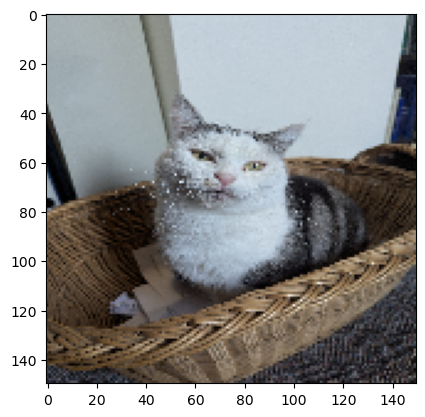

In [12]:
from keras.preprocessing import image
import numpy as np

#choose image from path
image_path = "/home/simon/Pictures/PXL_20251230_102837854.jpg"

# Pre-processing the image
img = image.load_img(image_path, target_size = (150, 150))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis = 0)
img_tensor = img_tensor / 255.

# Print image tensor shape
print(img_tensor.shape)

# Print image
import matplotlib.pyplot as plt
plt.imshow(img_tensor[0])
plt.show()

## Outputs of each layer

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
(1, 148, 148, 32)


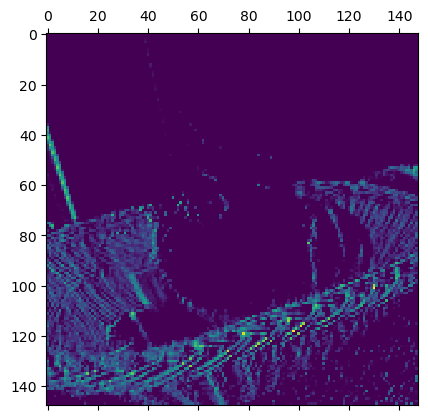

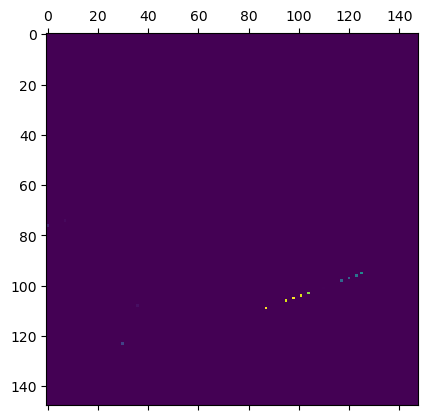

In [14]:
layer_outputs = [layer.output for layer in model.layers[:8]]

activation_model = models.Model(
    inputs = model.inputs,
    outputs = layer_outputs
)

activations = activation_model.predict(img_tensor)

#first layer activation
first_layer_activation = activations[0]

print(first_layer_activation.shape)

#channel 6
plt.matshow(first_layer_activation[0, :, :, 6], cmap = "viridis")

#channel 15
plt.matshow(first_layer_activation[0, :, :, 15], cmap = "viridis")

In [15]:
layer_names = []

#get layer names
for layer in model.layers[:8]:
  layer_names.append(layer.name)
print(layer_names)

['conv2d', 'max_pooling2d', 'conv2d_1', 'max_pooling2d_1', 'conv2d_2', 'max_pooling2d_2', 'conv2d_3', 'max_pooling2d_3']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
(1, 15, 15, 128)


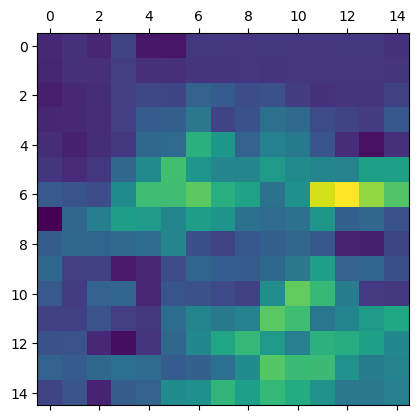

In [27]:
layer_name = "conv2d"

activation_model = models.Model(
    inputs = model.inputs,
    outputs = model.get_layer(layer_name).output
)

activations = activation_model.predict(img_tensor)

print(activations.shape)

plt.matshow(activations[0, :, :, 0], cmap = "viridis")
plt.savefig("/home/simon/Documents/ML_Python" + layer_name + "_layer_catsanddogs.jpg")
plt.show()

## Get feature map

In [36]:
from tensorflow.keras.layers import Conv2D

conv_layers = [layer for layer in model.layers if isinstance(layer, Conv2D)]

first_conv = conv_layers[0]
last_conv = conv_layers[-1]
print(first_conv.name)
print(last_conv.name)

conv2d
conv2d_3


In [29]:
#build activation model
activation_model = models.Model(
    inputs = model.inputs,
    outputs = first_conv.output
)

In [30]:
#get activations
activations = activation_model.predict(img_tensor)

print(activations.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
(1, 148, 148, 32)


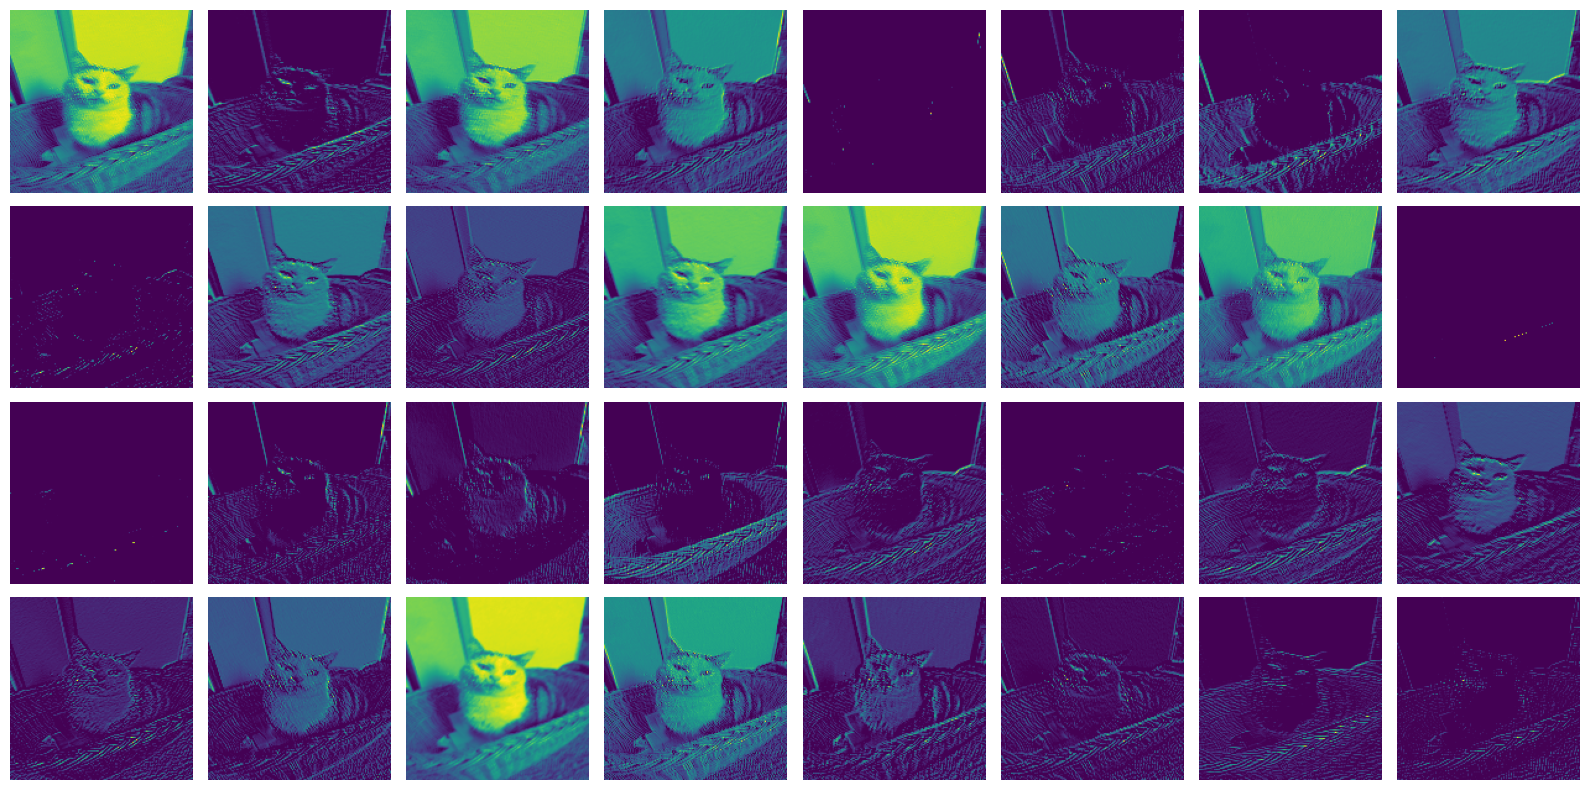

In [37]:
import math

#plot feature map for first conv layer
feature_maps = activations[0]  # remove batch dimension

n_features = feature_maps.shape[-1]

# grid size
cols = 8
rows = math.ceil(n_features / cols)

plt.figure(figsize = (cols * 2, rows * 2))

for i in range(n_features):
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(feature_maps[:, :, i], cmap = "viridis")
    plt.axis("off")

plt.tight_layout()
plt.savefig("/home/simon/Documents/ML_Python" + "feature_map_grid.jpg")
plt.show()

Last conv layer: conv2d_3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


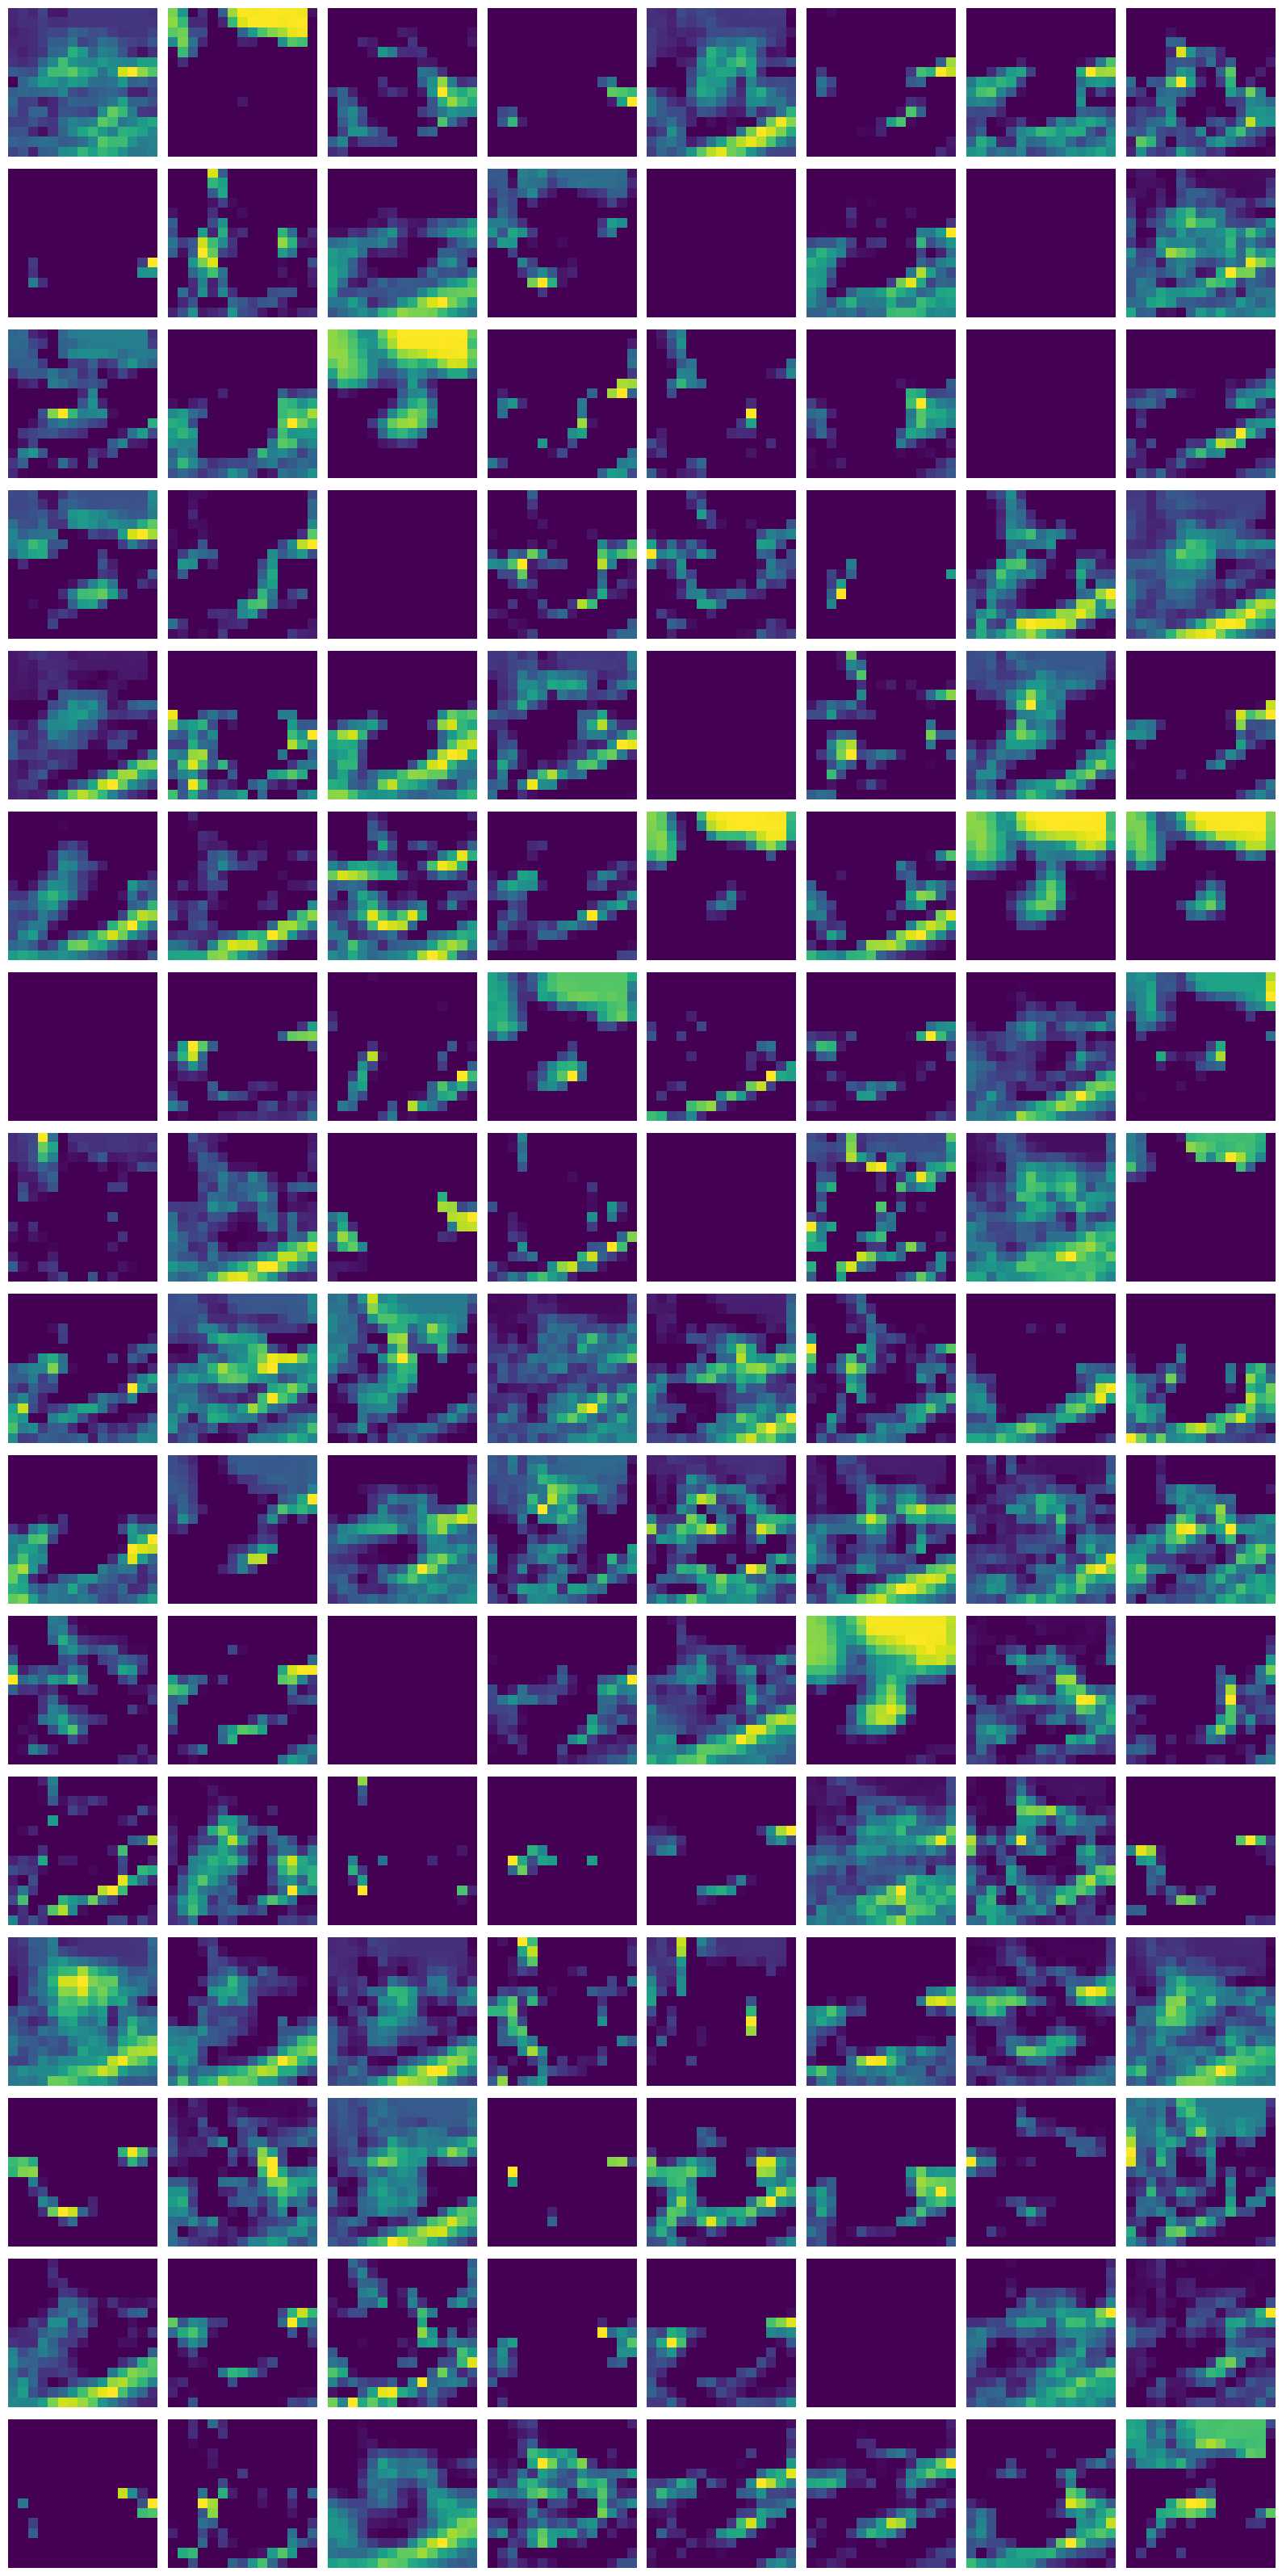

In [42]:
conv_layers = [layer for layer in model.layers if isinstance(layer, Conv2D)]
last_conv = conv_layers[-1]

print("Last conv layer:", last_conv.name)


activation_model = models.Model(
    inputs = model.inputs,
    outputs = last_conv.output
)

activations = activation_model.predict(img_tensor)

#plot feature map for last conf_layer

feature_maps = activations[0]
n_features = feature_maps.shape[-1]

cols = 8
rows = math.ceil(n_features / cols)

plt.figure(figsize = (cols * 2, rows * 2))

for i in range(n_features):
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(feature_maps[:, :, i], cmap = "viridis")
    plt.axis("off")

plt.tight_layout()
plt.savefig("/home/simon/Documents/ML_Python" + "last_feature_map_grid.jpg")
plt.show()